In [1]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [2]:
.libPaths()

[1] "/fast/home/y/ykazci/R/x86_64-unknown-linux-gnu-library/4.3"               
[2] "/gnu/store/5bw3l7k55lrjdcvgmb3q7c2vh7k61liy-profile/site-library"         
[3] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [3]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [9]:
# load the R environment with the necessary packages such as Epiregulon:

my_epiregulon_lib <- here::here("renv", "library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu")

In [10]:
my_epiregulon_lib

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"

In [11]:
.libPaths(new = my_epiregulon_lib, include.site = FALSE)

In [12]:
.libPaths()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"
[2] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [13]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp

'SeuratObject' was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall 'SeuratObject' as the ABI
for R may have changed


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t




In [15]:
list.files(here::here('r_objects')) |> print()

[1] "GeneExpressionMatrix.RDS"          "PeakMatrix.RDS"                   
[3] "mannens_et_al_seurat_modified.RDS" "mannens_et_al_seurat_obj.RDS"     
[5] "metadata.RDS"                      "pca_atac_by_bpcells_package.RDS"  
[7] "pca_rna_by_bpcells_package.RDS"    "umap_atac_by_bpcells_package.RDS" 
[9] "umap_rna_by_bpcells_package.RDS"  


In [16]:
mannens_et_al_seurat_modified <- 
    readRDS(here::here('r_objects', "mannens_et_al_seurat_modified.RDS"))

In [17]:
mannens_et_al_seurat_modified

Loading required package: Signac



An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 5 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap

In [18]:
mannens_et_al_seurat_modified |> levels()

[1] "10X280" "10X290" "10X346" "10X365" "10X370" "10X402" "10X406"

In [19]:
Idents(mannens_et_al_seurat_modified) <- 'main_cell_types'

In [22]:
my_colours = c(
    "#5A5156FF", "#F6222EFF", "#FE00FAFF", "#16FF32FF",
    "#3283FEFF", "#FEAF16FF", "#B00068FF", "#1CFFCEFF", "#90AD1CFF",
    "#2ED9FFFF", "#DEA0FDFF", "#AA0DFEFF", "#F8A19FFF", "#325A9BFF",
    "#C4451CFF", "#1C8356FF", "#85660DFF", "#B10DA1FF", "#FBE426FF",
    "#1CBE4FFF", "#FA0087FF", "#FC1CBFFF", "#F7E1A0FF", "#C075A6FF",
    "#782AB6FF", "#AAF400FF", "#BDCDFFFF", "#822E1CFF", "#B5EFB5FF",
    "#7ED7D1FF", "#1C7F93FF", "#D85FF7FF", "#683B79FF", "#66B0FFFF",
    "#3B00FBFF"
)

In [23]:
options(repr.plot.width = 15, repr.plot.height = 7)

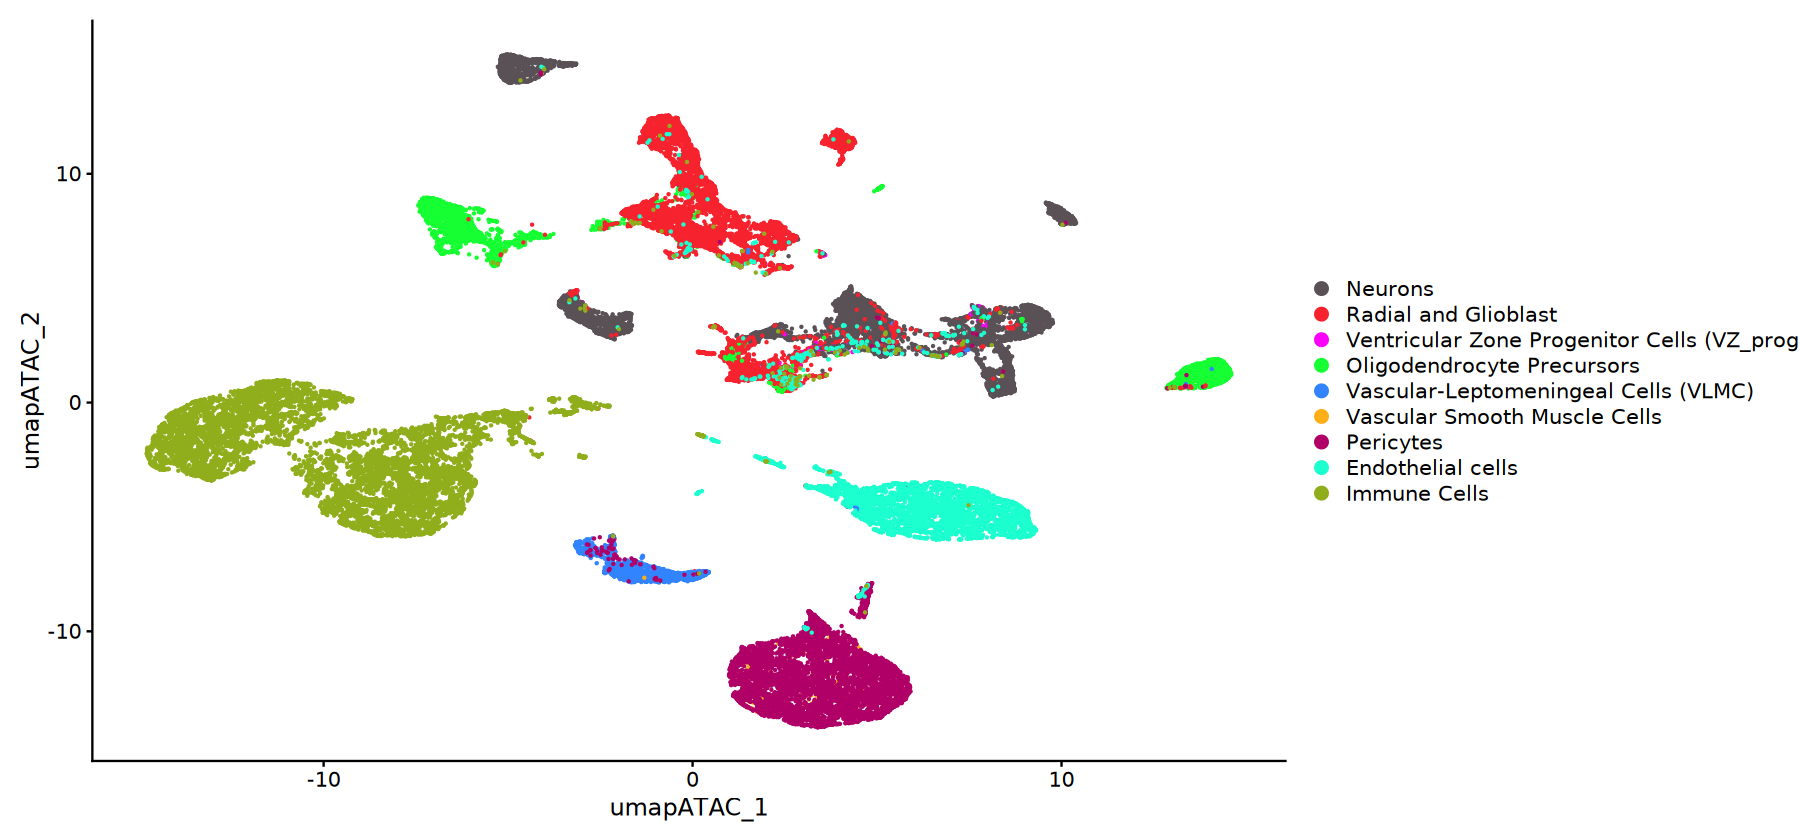

In [25]:
DimPlot(object = mannens_et_al_seurat_modified, 
        reduction = "umap_atac", 
        cols = my_colours)

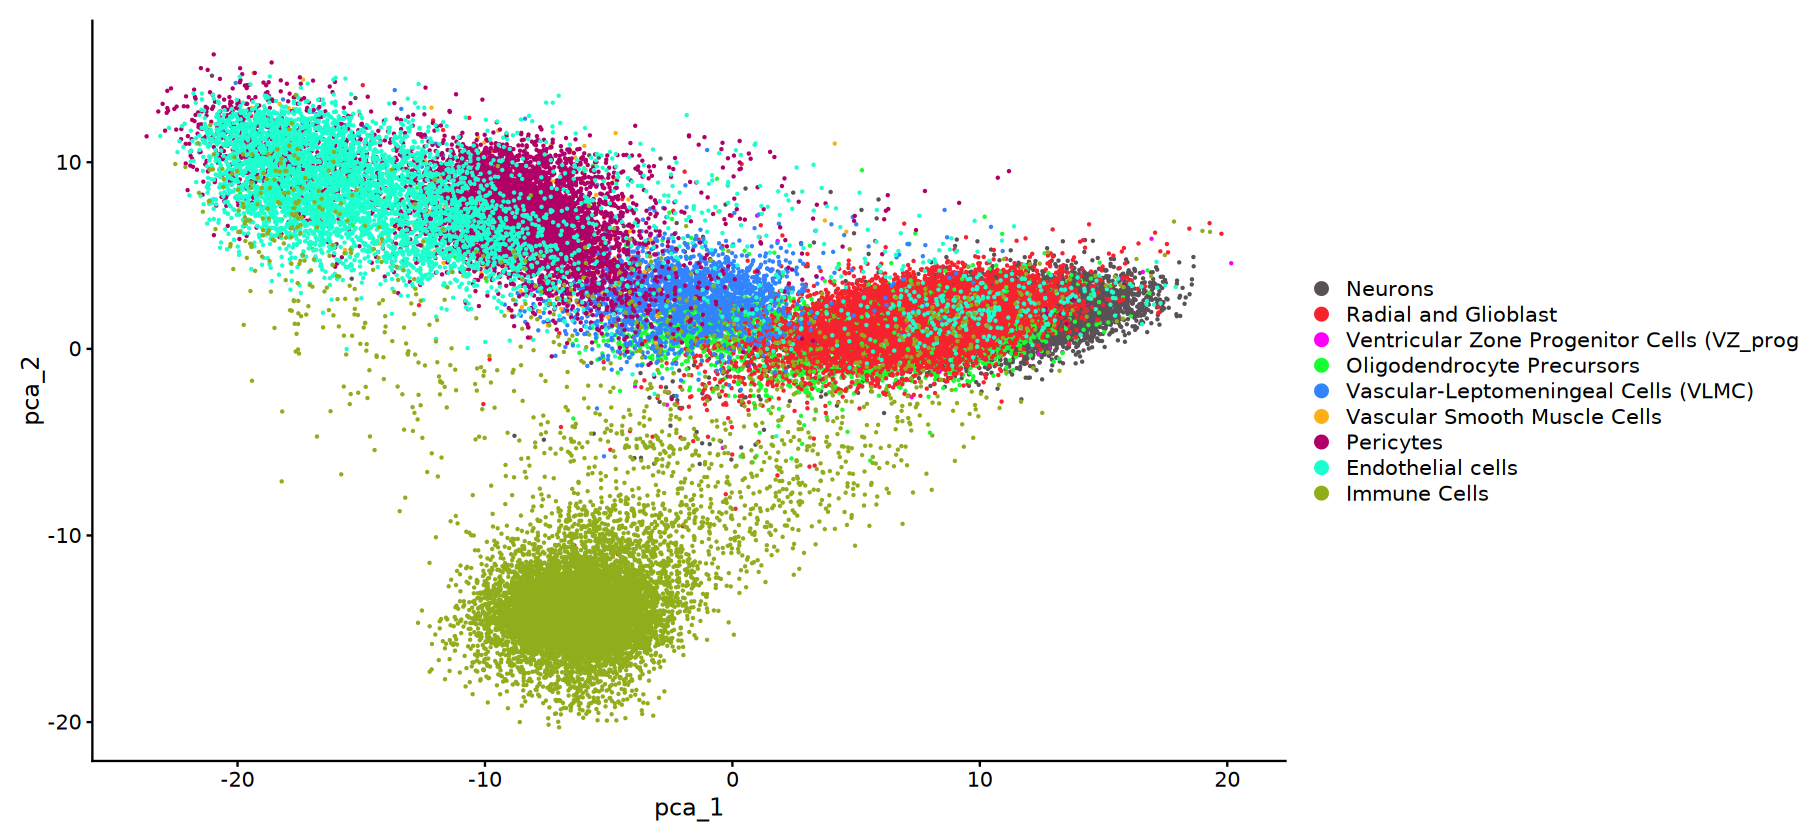

In [26]:
DimPlot(object = mannens_et_al_seurat_modified, 
        reduction = "pca", 
        cols = my_colours)

In [30]:
mannens_et_al_seurat_modified |> slot(name = 'meta.data') |> head()

,orig.ident,nCount_RNA,nFeature_RNA,before_filtering_orig.ident,before_filtering_nCount_RNA,before_filtering_nFeature_RNA,_index,Age,Agetext,Ageunit,...,before_filtering_percent.mt,UMAP_1,UMAP_2,PC_1,PC_2,PC_3,PC_4,main_cell_types,RNA.weight,peaks.weight
,<fct>,<dbl>,<int>,<fct>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
10X280_1:CAGATTCAGCAGCTCA,10X280,4735,2198,10X280,4936,2346,10X280_1:CAGATTCAGCAGCTCA,7.6,7.6w,pcw,...,0,-6.222241,13.43640,-4.106550,-3.268812,-6.732936,-3.938670,Neurons,0.23593577,0.7640642
10X365_2:ACCAATATCAATGACC,10X365,4031,1628,10X365,4243,1759,10X365_2:ACCAATATCAATGACC,9.5,9.5w,pcw,...,0,-4.132537,11.84413,-4.832493,-3.687770,-7.308814,-4.725655,Neurons,0.14260259,0.8573974
10X365_2:ATGGTGCGTCACCTAT,10X365,4454,1277,10X365,4677,1368,10X365_2:ATGGTGCGTCACCTAT,9.5,9.5w,pcw,...,0,-4.506521,11.84385,-3.591811,-3.051787,-5.394616,-3.315939,Neurons,0.07421379,0.9257862
10X280_1:ACACCTTGTCATTAGG,10X280,3976,1850,10X280,4173,1982,10X280_1:ACACCTTGTCATTAGG,7.6,7.6w,pcw,...,0,-6.333588,12.94526,-4.587127,-3.315104,-6.001663,-3.448300,Neurons,0.45593400,0.5440660
10X406_1:TATCGCGAGGCTTAAC,10X406,3896,1631,10X406,4125,1780,10X406_1:TATCGCGAGGCTTAAC,9.5,9.5w,pcw,...,0,-4.288225,12.16204,-5.145256,-2.662943,-6.679519,-5.007179,Neurons,0.23603171,0.7639683
10X280_1:ACCTTGCTCCGTAAAC,10X280,3794,1556,10X280,3973,1664,10X280_1:ACCTTGCTCCGTAAAC,7.6,7.6w,pcw,...,0,-6.127756,13.72135,-4.534543,-3.120566,-5.102031,-3.038839,Neurons,0.54242474,0.4575753


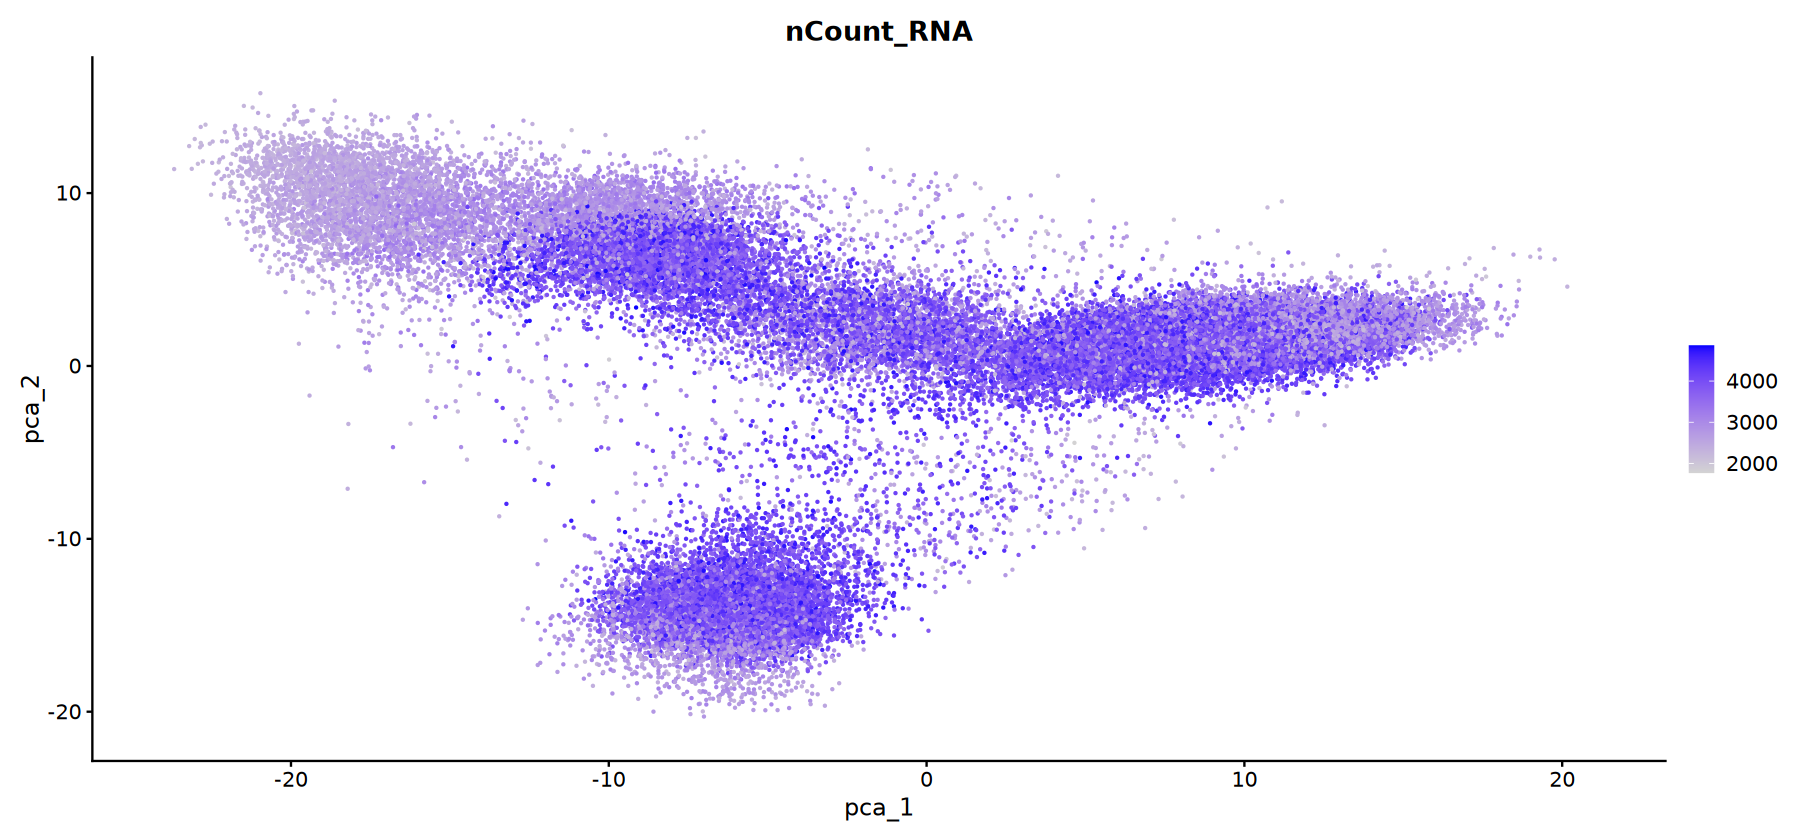

In [32]:
FeaturePlot(object = mannens_et_al_seurat_modified,
            features = "nCount_RNA",  
            reduction = "pca")

In [36]:
mannens_et_al_seurat_modified |> _@meta.data |> colnames()

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "before_filtering_orig.ident"  
 [5] "before_filtering_nCount_RNA"   "before_filtering_nFeature_RNA"
 [7] "_index"                        "Age"                          
 [9] "Agetext"                       "Ageunit"                      
[11] "All_fc_analysis_id"            "Analysis"                     
[13] "CellCycle"                     "CellCycle_G1"                 
[15] "CellCycle_G2M"                 "CellCycle_S"                  
[17] "CellID"                        "Chemistry"                    
[19] "Class"                         "ClusterName"                  
[21] "Clusters"                      "Clusters_main"                
[23] "Clusters_peaks"                "Clusters_renumbered"          
[25] "Cmobarcodes"                   "Comment"                      
[27] "Datecaptured"                  "Donor"                        
[29] "DoubletFinderFlag"             "DoubletFinderScore"           
[31] "Editat"                        "Editby"                       
[33] "FRIP"                          "FRtss"                        
[35] "GA_colsum"                     "GA_pooled_colsum"             
[37] "Id"                            "IsCycling"                    
[39] "Label"                         "Method"                       
[41] "NBins"                         "NGenes"                       
[43] "NPeaks"                        "Name"                         
[45] "Neuronprop"                    "Numpooledanimals"             
[47] "Outliers"                      "Plugdate"                     
[49] "Project"                       "PseudoAge"                    
[51] "Roi"                           "SEX"                          
[53] "Sampleok"                      "Sex"                          
[55] "Shortname"                     "Species"                      
[57] "Split"                         "Splits"                       
[59] "Strain"                        "SubClusters"                  
[61] "TSS_fragments"                 "Tissue"                       
[63] "TotalUMI"                      "Transcriptome"                
[65] "Y"                             "barcode"                      
[67] "chimeric"                      "duplicate"                    
[69] "excluded_reason"               "is__cell_barcode"             
[71] "lowmapq"                       "mitochondrial"                
[73] "passed_filters"                "peak_region_cutsites"         
[75] "peak_region_fragments"         "preClusters"                  
[77] "regions"                       "subregions"                   
[79] "total"                         "unmapped"                     
[81] "before_filtering_percent.mt"   "UMAP_1"                       
[83] "UMAP_2"                        "PC_1"                         
[85] "PC_2"                          "PC_3"                         
[87] "PC_4"                          "main_cell_types"              
[89] "RNA.weight"                    "peaks.weight"

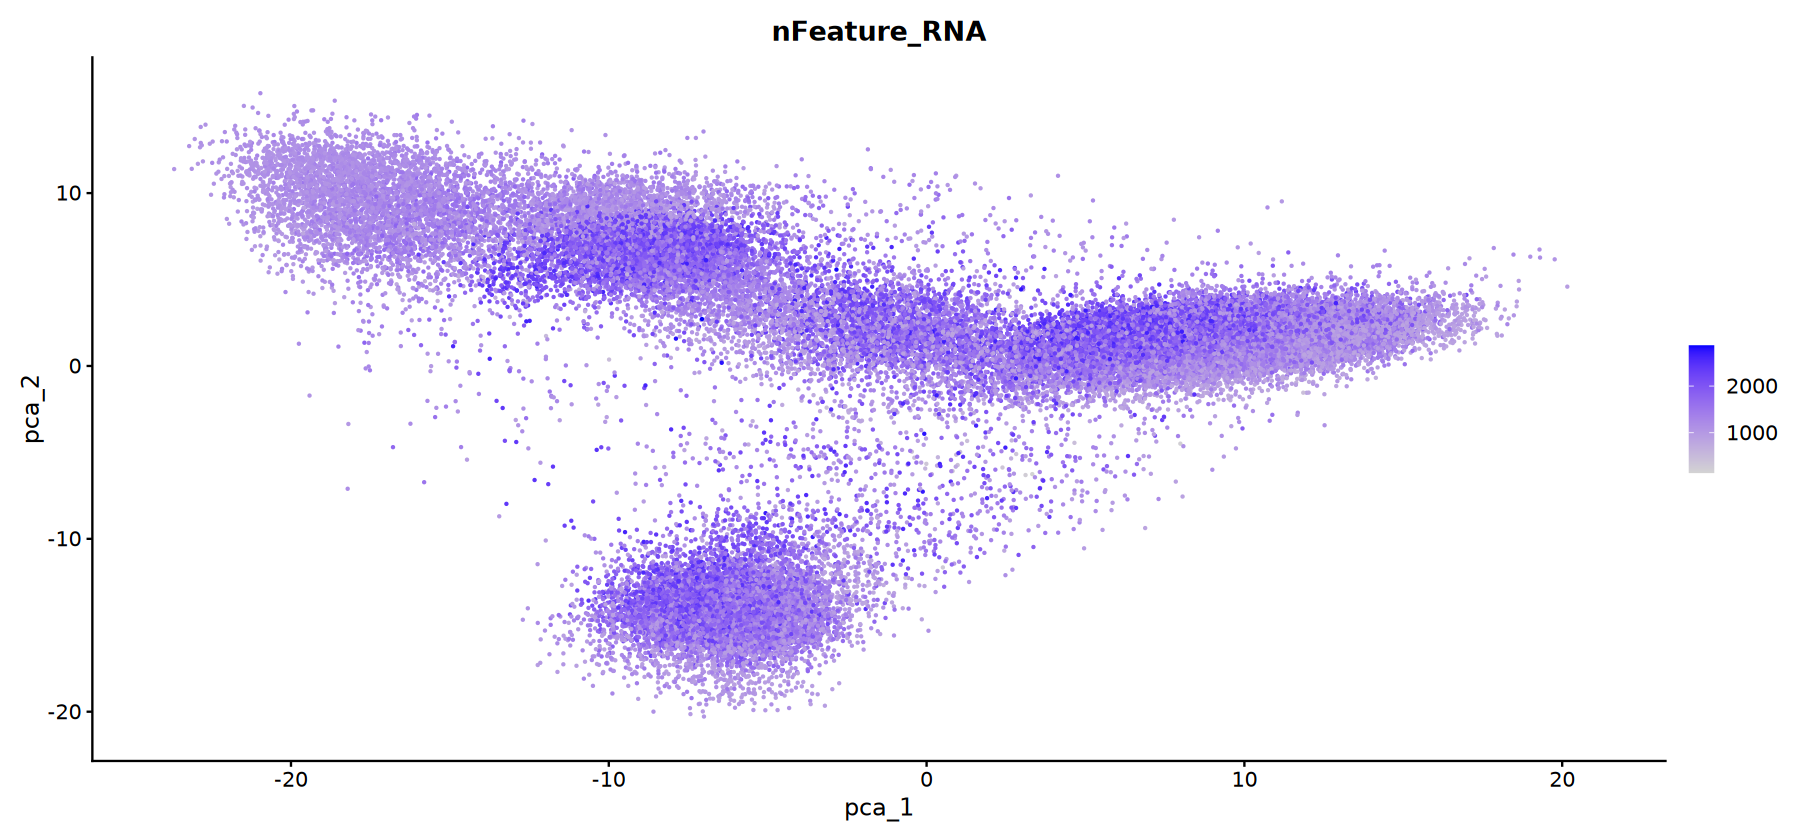

In [37]:
FeaturePlot(object = mannens_et_al_seurat_modified,
            features = "nFeature_RNA",  
            reduction = "pca")

mannens_et_al_seurat_modified@meta.data |> str()

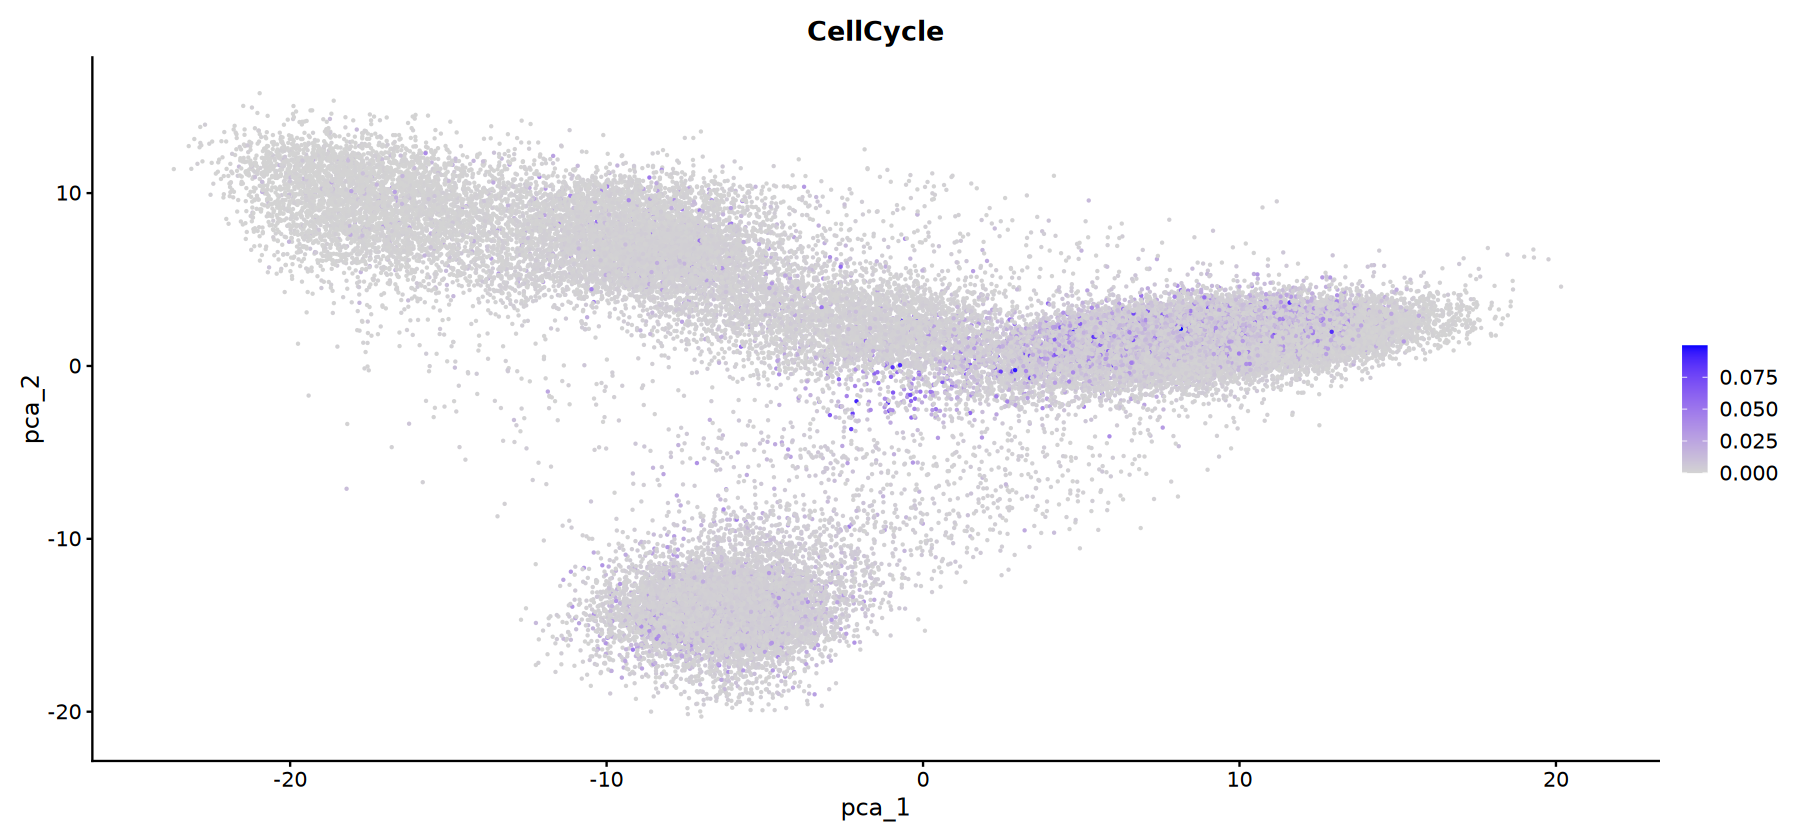

In [39]:
FeaturePlot(object = mannens_et_al_seurat_modified,
            features = "CellCycle",  
            reduction = "pca")

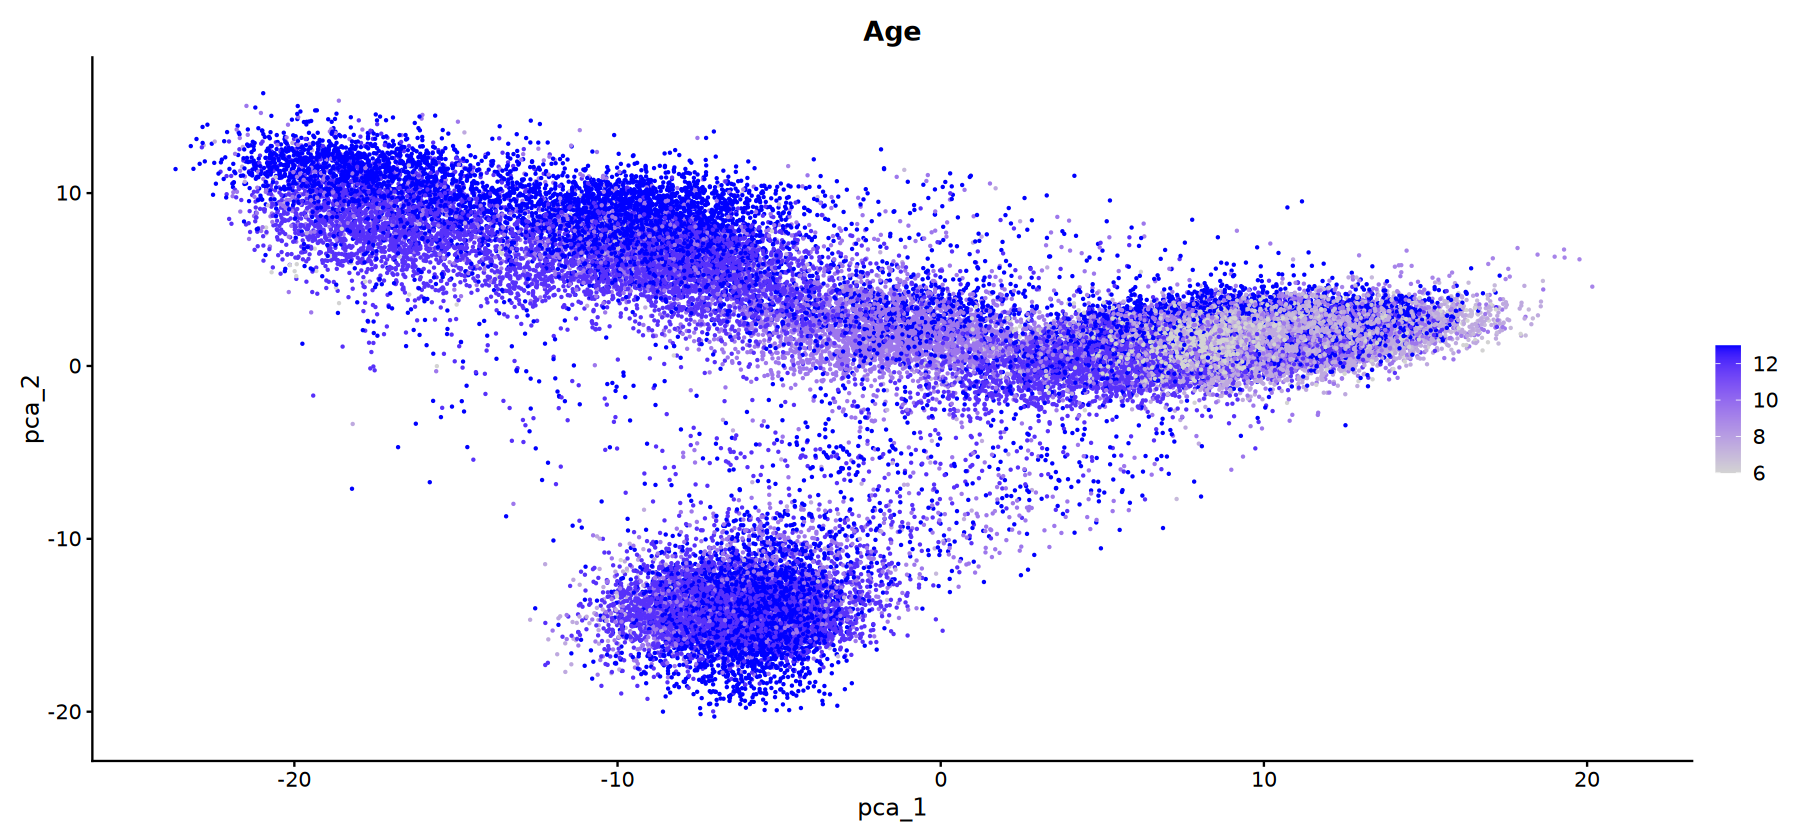

In [40]:
FeaturePlot(object = mannens_et_al_seurat_modified,
            features = "Age",  
            reduction = "pca")

In [53]:
ls()

[1] "mannens_et_al_seurat_modified" "my_colours"                   
[3] "my_epiregulon_lib"

In [55]:
scMultiome::reprogramSeq()

see ?scMultiome and browseVignettes('scMultiome') for documentation

downloading 1 resources

retrieving 1 resource

loading from cache



A MultiAssayExperiment object of 6 listed
 experiments with user-defined names and respective classes.
 Containing an ExperimentList class object of length 6:
 [1] TileMatrix500: SingleCellAccessibilityExperiment with 6062095 rows and 3903 columns
 [2] GeneExpressionMatrix: SingleCellExperiment with 36438 rows and 3903 columns
 [3] GeneScoreMatrix: SingleCellExperiment with 24919 rows and 3903 columns
 [4] NEPCMatrix: SingleCellExperiment with 2 rows and 3903 columns
 [5] PeakMatrix: SingleCellExperiment with 126602 rows and 3903 columns
 [6] TF_bindingMatrix: SingleCellExperiment with 1274 rows and 3903 columns
Functionality:
 experiments() - obtain the ExperimentList instance
 colData() - the primary/phenotype DataFrame
 sampleMap() - the sample coordination DataFrame
 `$`, `[`, `[[` - extract colData columns, subset, or experiment
 *Format() - convert into a long or wide DataFrame
 assays() - convert ExperimentList to a SimpleList of matrices
 exportClass() - save data to flat files

In [56]:
esample_sce <- scMultiome::reprogramSeq()

see ?scMultiome and browseVignettes('scMultiome') for documentation

loading from cache



In [57]:
# typo:

example_sce <- esample_sce

In [58]:
rm(esample_sce)

In [59]:
example_sce

A MultiAssayExperiment object of 6 listed
 experiments with user-defined names and respective classes.
 Containing an ExperimentList class object of length 6:
 [1] TileMatrix500: SingleCellAccessibilityExperiment with 6062095 rows and 3903 columns
 [2] GeneExpressionMatrix: SingleCellExperiment with 36438 rows and 3903 columns
 [3] GeneScoreMatrix: SingleCellExperiment with 24919 rows and 3903 columns
 [4] NEPCMatrix: SingleCellExperiment with 2 rows and 3903 columns
 [5] PeakMatrix: SingleCellExperiment with 126602 rows and 3903 columns
 [6] TF_bindingMatrix: SingleCellExperiment with 1274 rows and 3903 columns
Functionality:
 experiments() - obtain the ExperimentList instance
 colData() - the primary/phenotype DataFrame
 sampleMap() - the sample coordination DataFrame
 `$`, `[`, `[[` - extract colData columns, subset, or experiment
 *Format() - convert into a long or wide DataFrame
 assays() - convert ExperimentList to a SimpleList of matrices
 exportClass() - save data to flat files

In [60]:
example_sce@ExperimentList$GeneExpressionMatrix |> head()

class: SingleCellExperiment 
dim: 6 3903 
metadata(1): .internal
assays(2): counts normalizedCounts
rownames(6): MIR1302-2HG FAM138A ... AL627309.3 AL627309.2
rowData names(2): name strand.1
colnames(3903): reprogram#TTAGGAACAAGGTACG-1
  reprogram#GAGCGGTCAACCTGGT-1 ... reprogram#GGTTACTAGACACCGC-1
  reprogram#CGCTATGAGTGAACAG-1
colData names(23): BlacklistRatio DoubletEnrichment ... ReadsInPeaks
  FRIP
reducedDimNames(2): LSI_RNA UMAP_RNA
mainExpName: NULL
altExpNames(0):

In [62]:
gexp_mat <- example_sce@ExperimentList$GeneExpressionMatrix

In [63]:
gexp_mat

class: SingleCellExperiment 
dim: 36438 3903 
metadata(1): .internal
assays(2): counts normalizedCounts
rownames(36438): MIR1302-2HG FAM138A ... IL9R WASIR1
rowData names(2): name strand.1
colnames(3903): reprogram#TTAGGAACAAGGTACG-1
  reprogram#GAGCGGTCAACCTGGT-1 ... reprogram#GGTTACTAGACACCGC-1
  reprogram#CGCTATGAGTGAACAG-1
colData names(23): BlacklistRatio DoubletEnrichment ... ReadsInPeaks
  FRIP
reducedDimNames(2): LSI_RNA UMAP_RNA
mainExpName: NULL
altExpNames(0):

==========================================

IMPORTANT NOTE:

In the assays slot, the matrix is named as "normalizedCounts"\
because it is extracted from an ArchR project object and \
contains counts that were normalized but NOT LOGGED.

For clarity, authors renamed this layer of counts 
as "normalizedCounts".

GeneExpressionMatrix <- ArchRMatrix2SCE(rse = GeneExpressionMatrix, rename = "normalizedCounts")

Interestingly, they also state in the bookdown documentation that\
this matrix can also be extracted with log transformatin option:

GeneExpressionMatrix <- ArchRMatrix2SCE(rse = GeneExpressionMatrix, transform = TRUE, transform_method = "log", log_name = "logcounts")

When they use this dataset in Epiregulon workflow, they use \
"normalizedCounts" assay directly. I will check if epiregulon\
log transforms the gene expression matrix inherently.

===========================================

In [69]:
epiregulon::calculateActivity |> args()

function (expMatrix = NULL, exp_assay = "logcounts", regulon = NULL, 
    normalize = FALSE, mode = "weight", method = c("weightedmean", 
        "aucell"), genesets = NULL, clusters = NULL, FUN = c("mean", 
        "sum"), ncore = 1, BPPARAM = BiocParallel::SerialParam()) 
NULL

In [70]:
epiregulon::calculateP2G |> args()

function (peakMatrix = NULL, expMatrix = NULL, reducedDim = NULL, 
    useDim = "IterativeLSI", maxDist = 250000, cor_cutoff = 0.5, 
    cellNum = 100, exp_assay = "logcounts", peak_assay = "counts", 
    gene_symbol = "name", clusters = NULL, cor_method = c("pearson", 
        "kendall", "spearman"), assignment_method = c("correlation", 
        "nearest"), frac_RNA = 0, frac_ATAC = 0, BPPARAM = BiocParallel::SerialParam()) 
NULL

================================================================

OK, so we find out that the default assay for gene expression\
is "logcounts" and for peak assay, it is "counts."

In [71]:
rm(gexp_mat)

In [72]:
rm(example_sce)

In [73]:
ls()

[1] "mannens_et_al_seurat_modified" "my_colours"                   
[3] "my_epiregulon_lib"

In [85]:
# I will load the single cell experiment objects containing
# RNA and peak matrices:

GeneExpressionMatrix <- readRDS(here::here('r_objects', 'GeneExpressionMatrix.RDS'))

In [86]:
GeneExpressionMatrix

class: SingleCellExperiment 
dim: 20667 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(20667): ENSG00000279457 ENSG00000237491 ... ENSG00000188120
  ENSG00000205944
rowData names(2): gene_id gene_name
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(89): orig.ident nCount_RNA ... main_cell_types ident
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [87]:
PeakMatrix <- readRDS(here::here('r_objects', 'PeakMatrix.RDS'))

In [88]:
PeakMatrix

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames: NULL
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(89): orig.ident nCount_RNA ... main_cell_types ident
reducedDimNames(0):
mainExpName: peaks
altExpNames(0):

In [90]:
PeakMatrix |> counts() |> head()

  [[ suppressing 34 column names '10X280_1:CAGATTCAGCAGCTCA', '10X365_2:ACCAATATCAATGACC', '10X365_2:ATGGTGCGTCACCTAT' ... ]]



6 x 49470 sparse Matrix of class "dgCMatrix"
                                                                               
[1,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
[2,] . . . . . . . . 1 . . . . . 1 1 . . 1 1 . . . . 1 . . . . 1 . . . . ......
[3,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
[4,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
[5,] . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
[6,] . . . . . . . . . . . . . . . . . . . . 2 . . . . . . . . . . . . . ......

 .....suppressing 49436 columns in show(); maybe adjust options(max.print=, width=)
 ..............................

In [91]:
mannens_et_al_seurat_modified

An object of class Seurat 
430192 features across 49470 samples within 2 assays 
Active assay: RNA (25071 features, 5000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 5 dimensional reductions calculated: pca, pca_atac, umap_rna, umap_atac, joint_umap

In [92]:
sce_mannens <- as.SingleCellExperiment(x = mannens_et_al_seurat_modified)

In [93]:
sce_mannens

class: SingleCellExperiment 
dim: 25071 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(25071): MALAT1 AUTS2 ... APOL5 SLURP1
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(1): peaks

In [94]:
sce_mannens |> altExp()

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames(405121): chr10-100006329-100006730 chr10-100009751-100010152
  ... chrY-7725786-7726187 chrY-7729552-7729953
rowData names(20): count percentile ... GC.percent sequence.length
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(0):
reducedDimNames(2): PCA_ATAC UMAP_ATAC
mainExpName: NULL
altExpNames(0):

In [99]:
sce_rna <- sce_mannens

In [100]:
sce_rna

class: SingleCellExperiment 
dim: 25071 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(25071): MALAT1 AUTS2 ... APOL5 SLURP1
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(1): peaks

In [103]:
sce_rna <- removeAltExps(x = sce_rna)

In [104]:
sce_rna

class: SingleCellExperiment 
dim: 25071 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(25071): MALAT1 AUTS2 ... APOL5 SLURP1
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(0):

In [105]:
sce_atac <- sce_mannens |> altExp()

In [106]:
sce_atac

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames(405121): chr10-100006329-100006730 chr10-100009751-100010152
  ... chrY-7725786-7726187 chrY-7729552-7729953
rowData names(20): count percentile ... GC.percent sequence.length
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(0):
reducedDimNames(2): PCA_ATAC UMAP_ATAC
mainExpName: NULL
altExpNames(0):

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


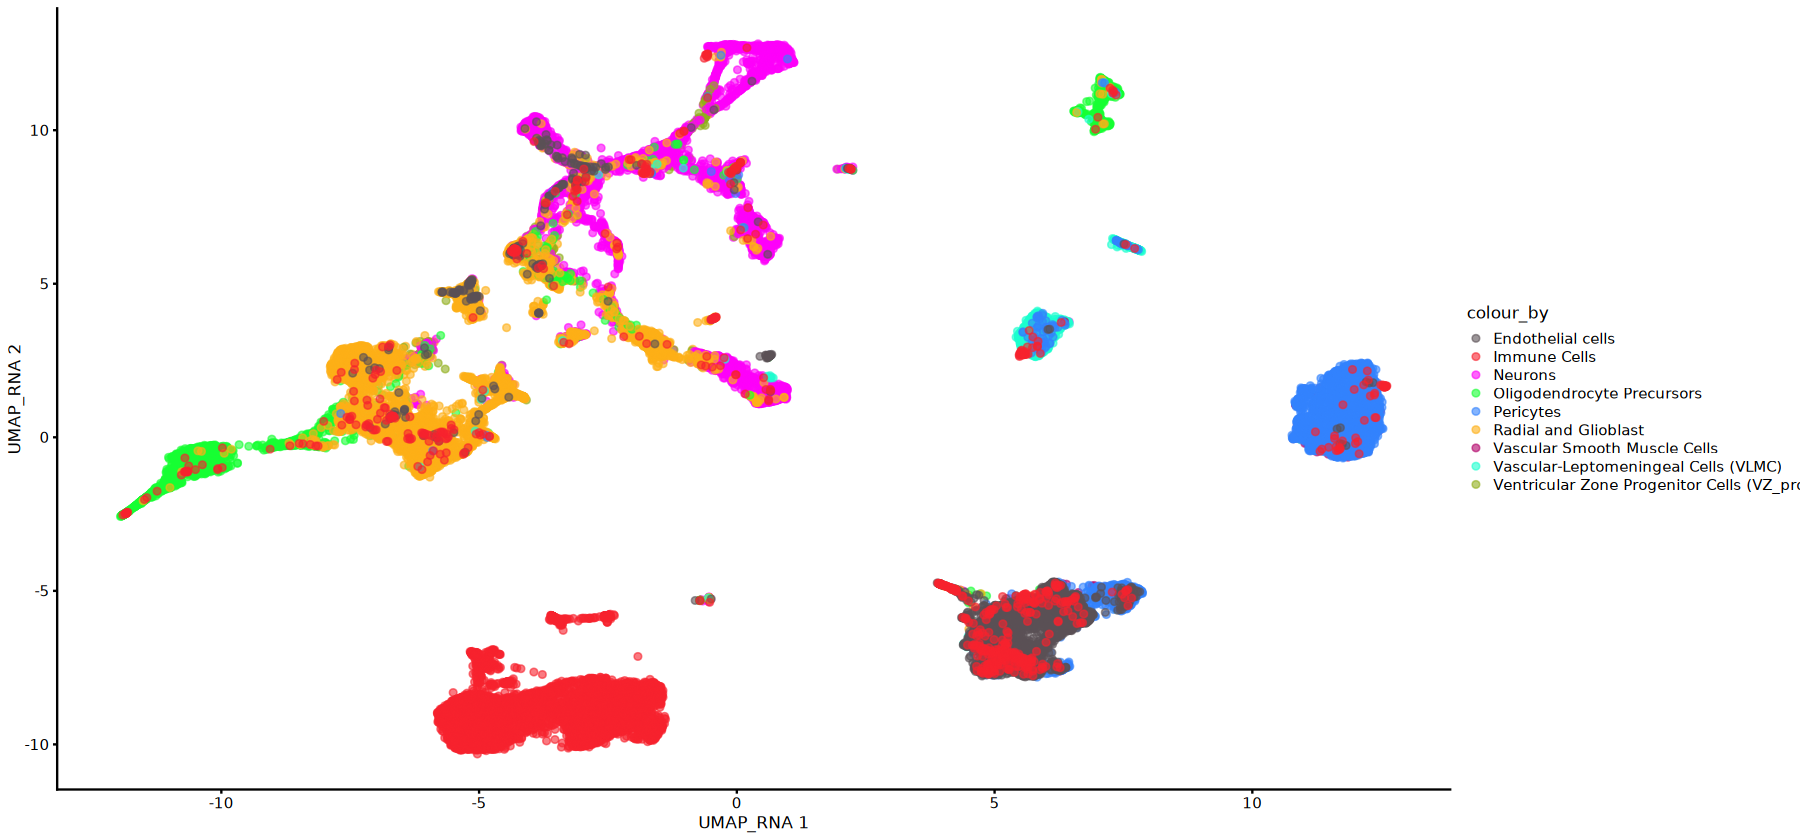

In [107]:
scater::plotReducedDim(sce_rna, 
                       dimred = "UMAP_RNA", 
                       # text_by = "Clusters", 
                       colour_by = "main_cell_types") + ggplot2::scale_color_manual(values = my_colours)

In [110]:
colData(sce_atac) <- colData(sce_rna)

In [111]:
rm(sce_ran)

In [112]:
rm(sce_mannens)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


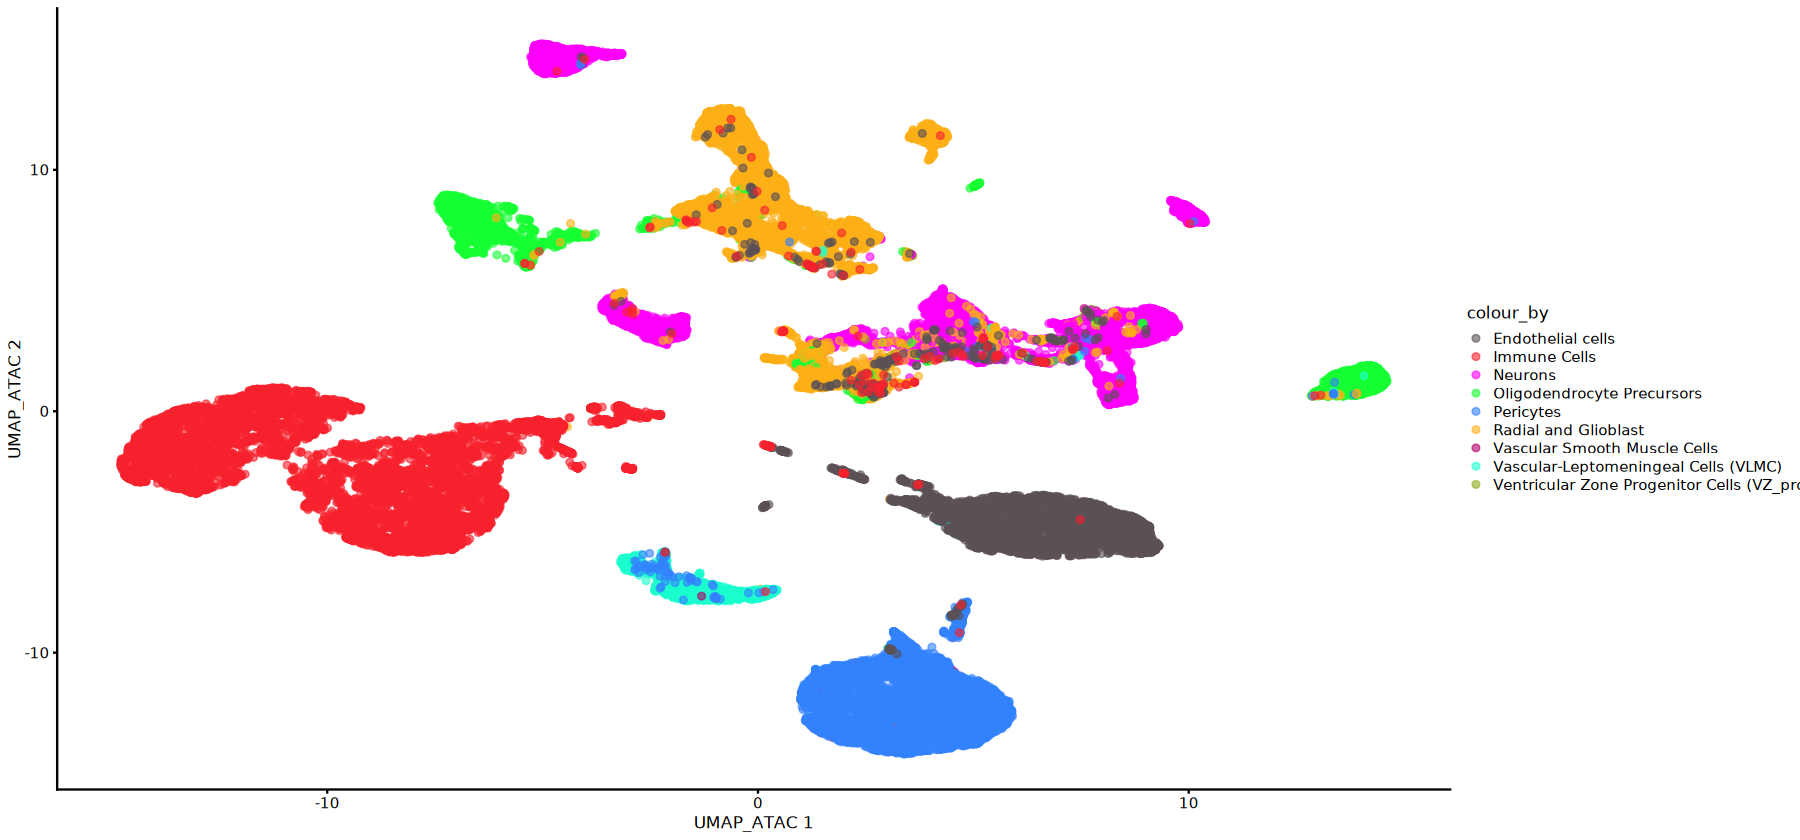

In [113]:
scater::plotReducedDim(sce_atac, 
                       dimred = "UMAP_ATAC", 
                       # text_by = "Clusters", 
                       colour_by = "main_cell_types") + ggplot2::scale_color_manual(values = my_colours)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


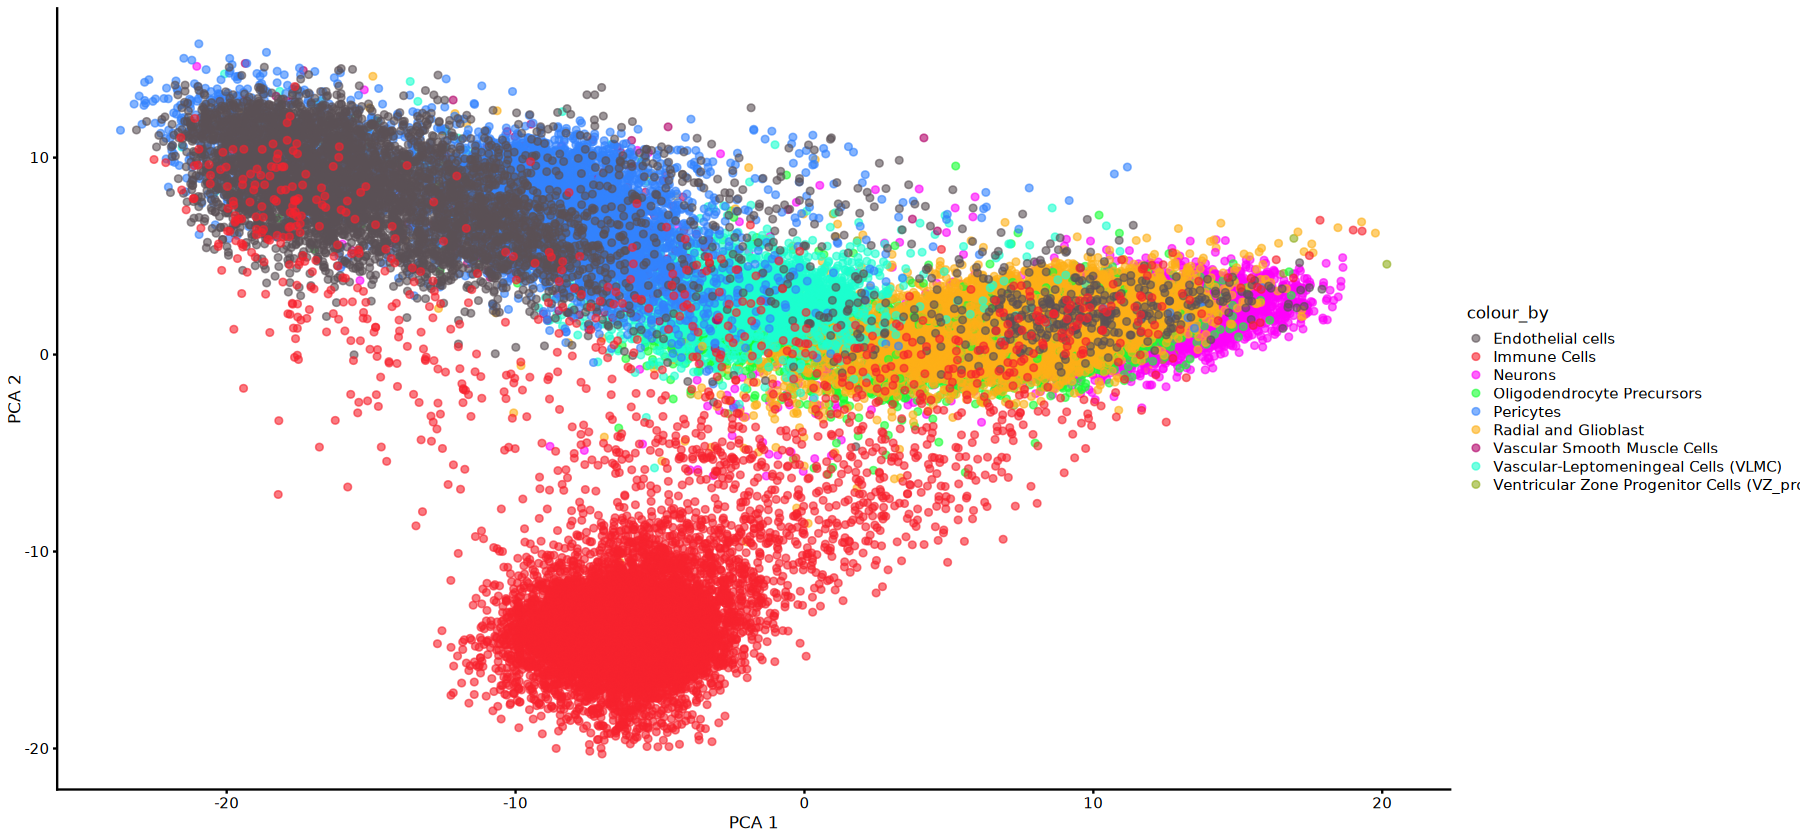

In [115]:
scater::plotReducedDim(sce_rna, 
                       dimred = "PCA", 
                       # text_by = "Clusters", 
                       colour_by = "main_cell_types") + ggplot2::scale_color_manual(values = my_colours)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


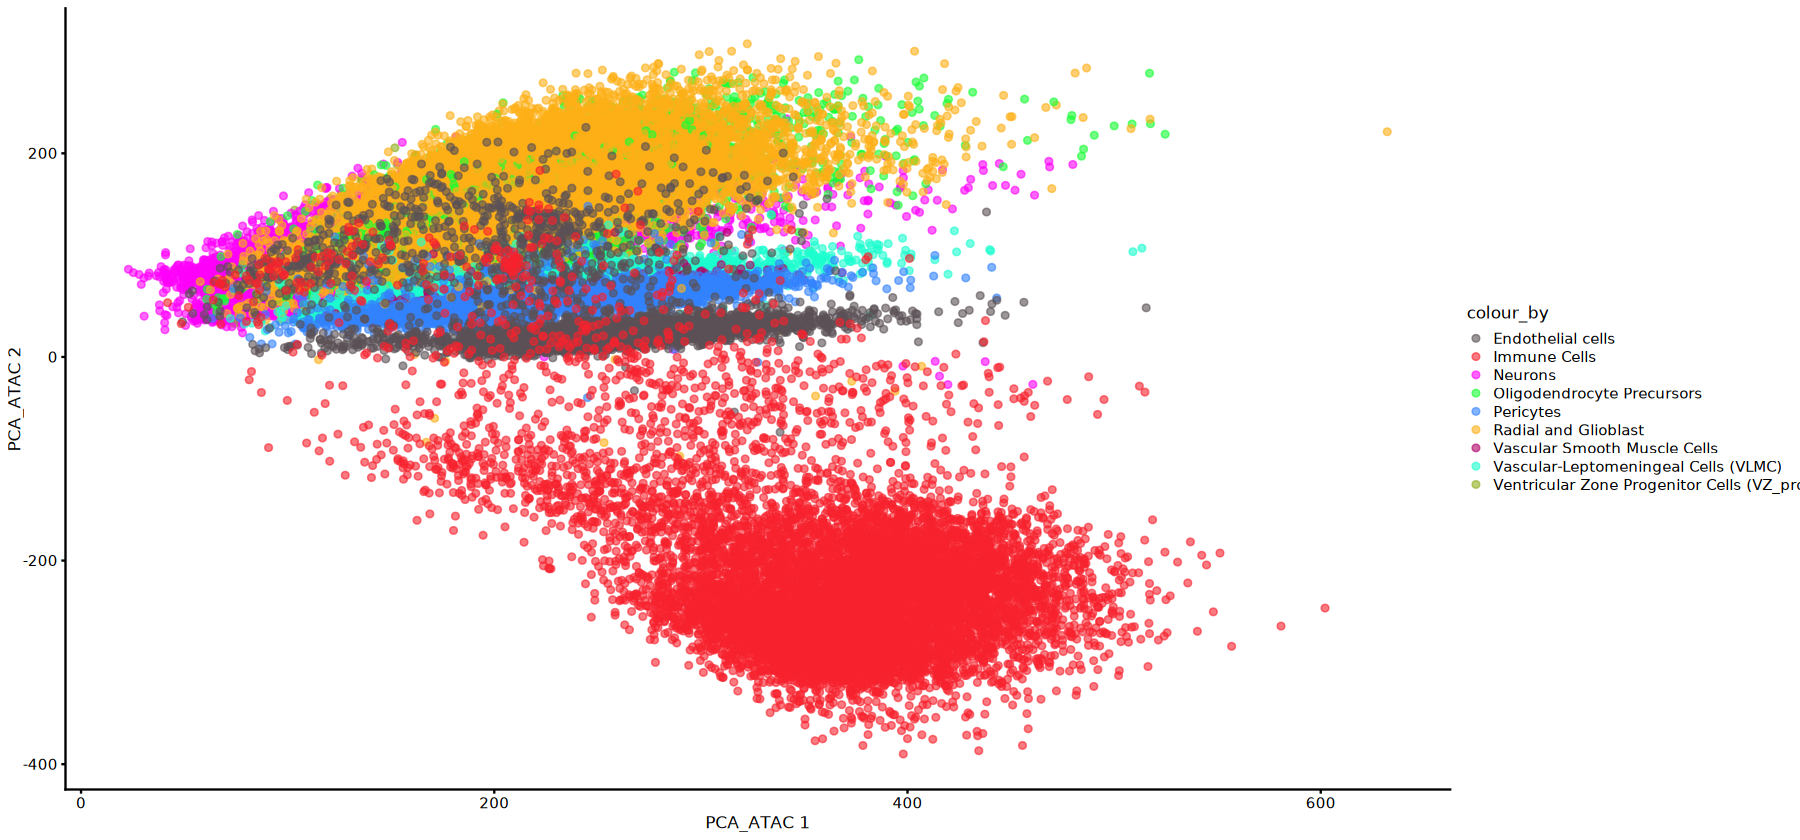

In [116]:
scater::plotReducedDim(sce_atac, 
                       dimred = "PCA_ATAC", 
                       # text_by = "Clusters", 
                       colour_by = "main_cell_types") + ggplot2::scale_color_manual(values = my_colours)

In [117]:
sce_rna

class: SingleCellExperiment 
dim: 25071 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(25071): MALAT1 AUTS2 ... APOL5 SLURP1
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(0):

In [118]:
sce_atac

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames(405121): chr10-100006329-100006730 chr10-100009751-100010152
  ... chrY-7725786-7726187 chrY-7729552-7729953
rowData names(20): count percentile ... GC.percent sequence.length
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(2): PCA_ATAC UMAP_ATAC
mainExpName: NULL
altExpNames(0):

In [119]:
sce_rna |> rowRanges()

GRangesList object of length 25071:
$MALAT1
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

$AUTS2
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

$NRXN1
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

...
<25068 more elements>

In [120]:
sce_atac |> rowRanges()

GRangesList object of length 405121:
$`chr10-100006329-100006730`
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

$`chr10-100009751-100010152`
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

$`chr10-100016741-100017142`
GRanges object with 0 ranges and 0 metadata columns:
   seqnames    ranges strand
      <Rle> <IRanges>  <Rle>
  -------
  seqinfo: no sequences

...
<405118 more elements>

In [121]:
# there are no gene or peak info at genome level.

In [122]:
# I need to retrieve genome region info of genes:

library(AnnotationHub)

In [123]:
ah <- AnnotationHub()

In [124]:
edb <- ah[["AH98047"]]  #"EnsDb.Hsapiens.v105"

loading from cache

require("ensembldb")



In [125]:
gr <- genes(edb, columns = c("gene_id", "gene_name"))

In [126]:
gr

GRanges object with 69329 ranges and 2 metadata columns:
                  seqnames            ranges strand |         gene_id
                     <Rle>         <IRanges>  <Rle> |     <character>
  ENSG00000223972        1       11869-14409      + | ENSG00000223972
  ENSG00000227232        1       14404-29570      - | ENSG00000227232
  ENSG00000278267        1       17369-17436      - | ENSG00000278267
  ENSG00000243485        1       29554-31109      + | ENSG00000243485
  ENSG00000284332        1       30366-30503      + | ENSG00000284332
              ...      ...               ...    ... .             ...
  ENSG00000224240        Y 26549425-26549743      + | ENSG00000224240
  ENSG00000227629        Y 26586642-26591601      - | ENSG00000227629
  ENSG00000237917        Y 26594851-26634652      - | ENSG00000237917
  ENSG00000231514        Y 26626520-26627159      - | ENSG00000231514
  ENSG00000235857        Y 56855244-56855488      + | ENSG00000235857
                    gene_name
   

In [127]:
common_genes <- na.omit(intersect(gr$gene_name, rownames(sce_rna)))

In [128]:
common_genes |> length()

[1] 20667

In [129]:
sce_rna <- sce_rna[common_genes,]

In [130]:
sce_rna

class: SingleCellExperiment 
dim: 20667 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(20667): WASH9P LINC01409 ... DAZ1 DAZ2
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(0):

In [132]:
rowRanges(sce_rna) <- gr[match(common_genes, gr$gene_name)]

In [133]:
rowRanges(sce_rna)

GRanges object with 20667 ranges and 2 metadata columns:
                  seqnames            ranges strand |         gene_id
                     <Rle>         <IRanges>  <Rle> |     <character>
  ENSG00000279457        1     185217-195411      - | ENSG00000279457
  ENSG00000237491        1     778747-810065      + | ENSG00000237491
  ENSG00000177757        1     817371-819837      + | ENSG00000177757
  ENSG00000230368        1     868071-876903      - | ENSG00000230368
  ENSG00000223764        1     916865-921016      - | ENSG00000223764
              ...      ...               ...    ... .             ...
  ENSG00000198692        Y 20575776-20593154      + | ENSG00000198692
  ENSG00000280969        Y 20756108-20781032      + | ENSG00000280969
  ENSG00000169789        Y 22490397-22514637      + | ENSG00000169789
  ENSG00000188120        Y 23129355-23199010      - | ENSG00000188120
  ENSG00000205944        Y 23219447-23291356      + | ENSG00000205944
                    gene_name
   

In [134]:
sce_rna

class: SingleCellExperiment 
dim: 20667 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(20667): ENSG00000279457 ENSG00000237491 ... ENSG00000188120
  ENSG00000205944
rowData names(2): gene_id gene_name
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(0):

In [136]:
# We then continue with preparation of PeakMatrix. After conversion to SingleCellExperiment, 
# the peak positions appear as rownames and must be converted to GRanges.

In [137]:
sce_atac

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames(405121): chr10-100006329-100006730 chr10-100009751-100010152
  ... chrY-7725786-7726187 chrY-7729552-7729953
rowData names(20): count percentile ... GC.percent sequence.length
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(2): PCA_ATAC UMAP_ATAC
mainExpName: NULL
altExpNames(0):

In [138]:
sce_atac |> rowData()

DataFrame with 405121 rows and 20 columns
                              count percentile        AA        AC        AG
                          <numeric>  <numeric> <numeric> <numeric> <numeric>
chr10-100006329-100006730      1523   0.794817        33        31        23
chr10-100009751-100010152     28117   0.989951         5         9        13
chr10-100016741-100017142       361   0.349468        51        18        19
chr10-100019766-100020167      1692   0.814448        28        14        26
chr10-100020276-100020677       698   0.595940        25        15        36
...                             ...        ...       ...       ...       ...
chrY-7703790-7704191             87  0.0117743        24        30        24
chrY-7714477-7714878            118  0.0338763        48        19        37
chrY-7724233-7724634            170  0.0953172        65        23        47
chrY-7725786-7726187            119  0.0348809        31        25        30
chrY-7729552-7729953            12

In [139]:
peak_position <- strsplit(rownames(sce_atac), split = "-")

In [140]:
peak_position |> head()

[[1]]
[1] "chr10"     "100006329" "100006730"

[[2]]
[1] "chr10"     "100009751" "100010152"

[[3]]
[1] "chr10"     "100016741" "100017142"

[[4]]
[1] "chr10"     "100019766" "100020167"

[[5]]
[1] "chr10"     "100020276" "100020677"

[[6]]
[1] "chr10"     "100020877" "100021278"

In [141]:
sapply(peak_position,"[",1) |> head()

[1] "chr10" "chr10" "chr10" "chr10" "chr10" "chr10"

In [142]:
sapply(peak_position,"[",2) |> head()

[1] "100006329" "100009751" "100016741" "100019766" "100020276" "100020877"

In [143]:
sapply(peak_position,"[",3) |> head()

[1] "100006730" "100010152" "100017142" "100020167" "100020677" "100021278"

In [144]:
gr <- GRanges(
    seqnames = sapply(peak_position,"[",1),
    ranges = IRanges(start = as.numeric(sapply(peak_position,"[",2)), 
                     end = as.numeric(sapply(peak_position,"[",3)))
)

In [145]:
gr

GRanges object with 405121 ranges and 0 metadata columns:
           seqnames              ranges strand
              <Rle>           <IRanges>  <Rle>
       [1]    chr10 100006329-100006730      *
       [2]    chr10 100009751-100010152      *
       [3]    chr10 100016741-100017142      *
       [4]    chr10 100019766-100020167      *
       [5]    chr10 100020276-100020677      *
       ...      ...                 ...    ...
  [405117]     chrY     7703790-7704191      *
  [405118]     chrY     7714477-7714878      *
  [405119]     chrY     7724233-7724634      *
  [405120]     chrY     7725786-7726187      *
  [405121]     chrY     7729552-7729953      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [146]:
rowRanges(sce_atac) <- gr

I checked the sce_rna and sce_atac objects and they are\
same with the previously generated PeakMatrix and \
GeneExpression Matrix sce objects. 

The only difference is extra columns in the colData\
that are transferred from the seurat object with the\
updated meta.data, along with the reductions calculated\
using BPCells package, lately.

In [150]:
# sce_rna |> 
#     saveRDS(here::here('r_objects', 'sce_rna_mannens.RDS'))

In [151]:
# sce_atac |> 
#     saveRDS(here::here('r_objects', 'sce_atac_mannens.RDS'))

In [152]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-unknown-linux-gnu
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gnu/store/mj1kw87qd3m1q7r4844adkn5hifx8k6a-openblas-0.3.20/lib/libopenblasp-r0.3.20.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C          LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C.UTF-8
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ensembldb_2.28.1            AnnotationFilter_1.28.0    
 [3] GenomicFeatures_1.56.0      AnnotationDbi_1.66.0       
 [5] scMultiome_1.4.2            SingleCellExperiment_1.26.0
 [7] MultiAssayExperiment_1.30.3 SummarizedExperiment_1.34.0
 [9] Biobase_2.64.0        